使用デバイス: cpu
学習を開始します... (データ数: 209枚, エポック数: 200)
Epoch [  1/200] | Total: 1750.7301 (MSE: 1750.6363, KLD: 0.0938)
Epoch [  2/200] | Total: 1492.6177 (MSE: 1491.1954, KLD: 1.4223)
Epoch [  3/200] | Total: 1229.1822 (MSE: 1229.0674, KLD: 0.1148)
Epoch [  4/200] | Total: 1132.1495 (MSE: 1132.0455, KLD: 0.1040)
Epoch [  5/200] | Total: 1063.6268 (MSE: 1063.5258, KLD: 0.1009)
Epoch [  6/200] | Total: 843.2713 (MSE: 843.1708, KLD: 0.1005)
Epoch [  7/200] | Total: 486.8857 (MSE: 486.7807, KLD: 0.1050)
Epoch [  8/200] | Total: 261.2735 (MSE: 261.1595, KLD: 0.1140)
Epoch [  9/200] | Total: 168.4671 (MSE: 168.3185, KLD: 0.1486)
Epoch [ 10/200] | Total: 124.2284 (MSE: 124.0861, KLD: 0.1422)
Epoch [ 11/200] | Total: 104.4504 (MSE: 104.3307, KLD: 0.1197)
Epoch [ 12/200] | Total: 90.4418 (MSE: 90.3367, KLD: 0.1051)
Epoch [ 13/200] | Total: 82.3794 (MSE: 82.2772, KLD: 0.1022)
Epoch [ 14/200] | Total: 76.2318 (MSE: 76.1323, KLD: 0.0995)
Epoch [ 15/200] | Total: 71.4796 (MSE: 71.3822, KLD: 0.0973)
Epoc

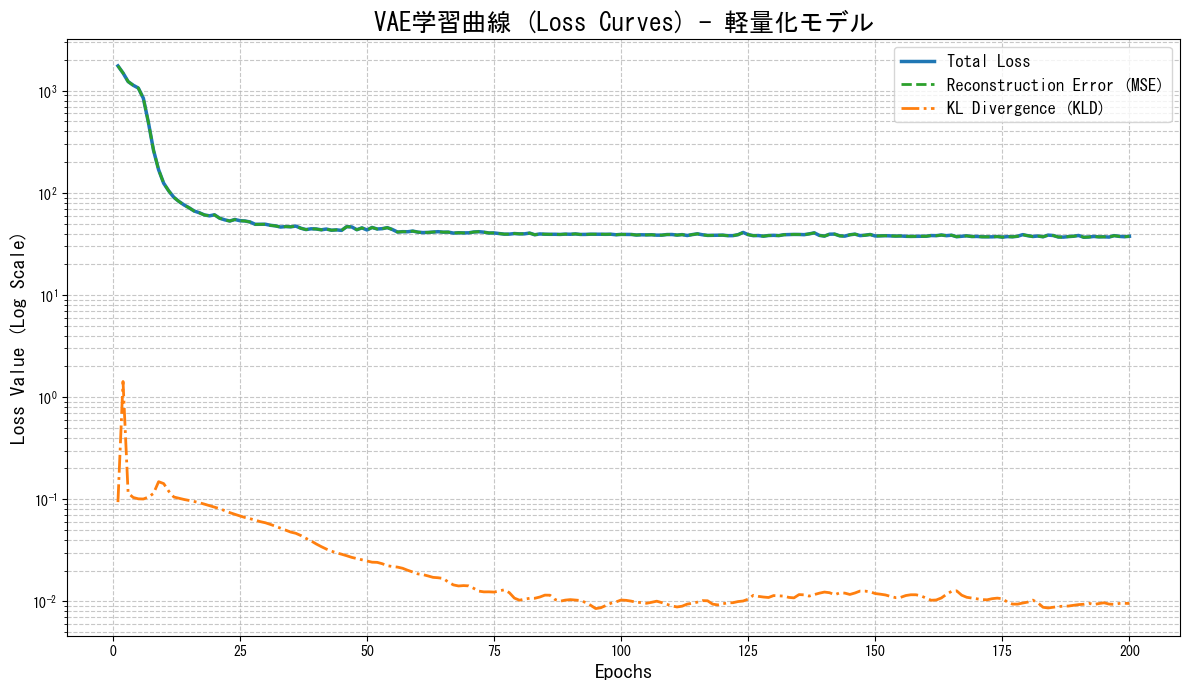

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# 日本語フォント設定 (japanize_matplotlibを使わず、Windows標準の日本語フォントを指定)
plt.rcParams['font.family'] = 'MS Gothic'

# =====================================================================
# 1. データセットと前処理の定義
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """train/good フォルダ内の正常画像のみを読み込むデータセット"""
        self.image_paths = list(Path(root_dir).glob("train/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# =====================================================================
# 2. VAEモデルの定義 (軽量化 / Light VAE 版)
# =====================================================================
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        
        # --- エンコーダ (5層) ---
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), nn.ReLU(),
        )
        
        # --- 潜在変数へのマッピング (全結合層の大幅カット) ---
        self.fc_hidden_enc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 128), nn.ReLU()
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # --- デコーダの入り口 (全結合層の大幅カット) ---
        self.fc_hidden_dec = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256 * 4 * 4), nn.ReLU()
        )

        # --- デコーダ (5層) ---
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        h = self.fc_hidden_enc(h)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_hidden_dec(z)
        h = h.view(-1, 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# =====================================================================
# 3. 損失関数
# =====================================================================
def vae_loss(recon_x, x, mu, logvar):
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + KLD

# =====================================================================
# 4. 学習ループ
# =====================================================================
if __name__ == "__main__":
    DATA_DIR = r"C:\Users\tokiy\image-anomaly-detection\data\bottle"
    
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")
    
    model = VAE(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    epochs = 200
    model.train()
    
    mse_history = []
    kld_history = []
    total_loss_history = []
    
    print(f"学習を開始します... (データ数: {len(dataset)}枚, エポック数: {epochs})")
    
    for epoch in range(epochs):
        train_mse = 0
        train_kld = 0
        train_total = 0
        
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataloader.dataset)
        avg_kld = train_kld / len(dataloader.dataset)
        avg_total = train_total / len(dataloader.dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f})")
            
    print("学習が完了しました！")
    
    # ★変更: 軽量化モデルであることを明記したファイル名に変更
    torch.save(model.state_dict(), "vae_bottle_model_128_light.pth")
    print("モデルを 'vae_bottle_model_128_light.pth' として保存しました。")
    
    # =================================================================
    # ★変更: 学習曲線の描画 (縦軸対数表示)
    # =================================================================
    plt.figure(figsize=(12, 7))
    
    plt.plot(range(1, epochs + 1), total_loss_history, color='#1f77b4', linewidth=2.5, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, color='#2ca02c', linewidth=2, linestyle='--', label='Reconstruction Error (MSE)')
    plt.plot(range(1, epochs + 1), kld_history, color='#ff7f0e', linewidth=2, linestyle='-.', label='KL Divergence (KLD)')
    
    plt.title('VAE学習曲線 (Loss Curves) - 軽量化モデル', fontsize=18, fontweight='bold')
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss Value (Log Scale)', fontsize=14)
    
    # ★追加: 縦軸を対数表示（Log Scale）に設定
    plt.yscale('log')
    # 対数スケールに合わせて、細かい補助線（マイナーグリッド）も表示
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()